# Predictive Maintenance using Machine Learning

## Problem Statement

Develop an end-to-end predictive maintenance system for a manufacturing client using highly imbalanced sensor data, where only 0.5% of observations represent machine failures.

## Objective

Build, tune, and evaluate machine learning models capable of detecting machine failures while handling severe class imbalance and incorporating business-cost based decision threshold optimization.

## Assignment Goals

- Generate synthetic sensor data
- Handle severe class imbalance
- Perform feature engineering
- Build end-to-end ML pipelines
- Compare multiple models
- Tune model hyperparameters
- Evaluate using imbalance-aware metrics
- Apply business-cost based threshold optimization

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.base import (
    BaseEstimator,
    TransformerMixin
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    PrecisionRecallDisplay,
    RocCurveDisplay
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import joblib

sns.set_style("whitegrid")

## 2. Generate Synthetic Dataset

In [2]:
X, y = make_classification(
    n_samples=100000,
    n_features=20,
    n_informative=12,
    n_redundant=4,
    n_classes=2,
    weights=[0.995, 0.005],
    flip_y=0,
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=[f"sensor_{i}" for i in range(20)]
)

df["failure"] = y

df.head()

,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,failure
0,-1.496596,3.598478,0.420355,-2.517875,-1.723906,-1.303456,4.360783,-0.736260,-1.013352,0.208285,...,-0.282840,3.471501,-0.752729,0.176620,3.571725,-0.004893,0.253209,-0.157769,0.561575,0
1,1.588427,0.021563,1.987999,0.814732,-1.959825,-1.203193,4.744014,-0.345622,3.169400,-4.283567,...,1.509545,0.646360,-1.167268,2.094629,0.930662,1.704498,0.044369,0.546866,-0.371378,0
2,1.248128,-0.350940,3.173332,4.828474,1.305101,0.508890,-1.153885,0.504817,2.421157,-0.173273,...,-0.551409,-2.552789,0.704865,0.934762,2.431484,1.189463,0.614756,0.949317,-3.506018,0
3,-5.018779,0.158361,-8.364981,-2.839102,-0.086872,-2.209352,4.211704,1.075300,-0.768315,2.954403,...,-0.522392,0.286686,0.813336,1.691189,4.166067,0.226361,0.270255,-1.552222,0.256674,0
4,1.839451,3.170041,-4.940358,-0.589623,1.255178,-4.591562,3.843878,0.676352,-2.028814,-0.908512,...,-0.538504,-0.623660,0.816275,-1.582429,-1.558232,2.071239,-0.100129,-1.241579,3.721558,0


## 4. Dataset Overview

In [3]:
print("Dataset Shape:", df.shape)

print("\nClass Distribution:")

print(df["failure"].value_counts())

Dataset Shape: (100000, 21)

Class Distribution:
failure
0    99500
1      500
Name: count, dtype: int64


## 5. Failure Rate Analysis

In [4]:
failure_rate = (
    df["failure"].mean() * 100
)

print(
    f"Failure Rate: {failure_rate:.2f}%"
)

Failure Rate: 0.50%


## 6. Class Imbalance Visualization

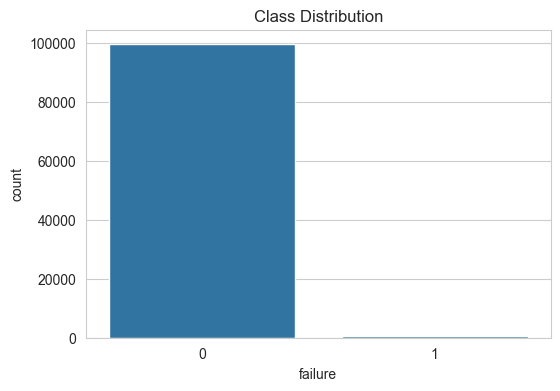

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df["failure"]
)

plt.title("Class Distribution")

plt.show()

## 7. Feature Engineering

In [6]:
df["sensor_ratio"] = (
    df["sensor_0"] /
    (df["sensor_1"].abs() + 1)
)

df["sensor_sum"] = (
    df["sensor_2"] +
    df["sensor_3"]
)

print("Updated Shape:", df.shape)

df.head()

Updated Shape: (100000, 23)


,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,failure,sensor_ratio,sensor_sum
0,-1.496596,3.598478,0.420355,-2.517875,-1.723906,-1.303456,4.360783,-0.736260,-1.013352,0.208285,...,-0.752729,0.176620,3.571725,-0.004893,0.253209,-0.157769,0.561575,0,-0.325455,-2.097519
1,1.588427,0.021563,1.987999,0.814732,-1.959825,-1.203193,4.744014,-0.345622,3.169400,-4.283567,...,-1.167268,2.094629,0.930662,1.704498,0.044369,0.546866,-0.371378,0,1.554899,2.802731
2,1.248128,-0.350940,3.173332,4.828474,1.305101,0.508890,-1.153885,0.504817,2.421157,-0.173273,...,0.704865,0.934762,2.431484,1.189463,0.614756,0.949317,-3.506018,0,0.923896,8.001806
3,-5.018779,0.158361,-8.364981,-2.839102,-0.086872,-2.209352,4.211704,1.075300,-0.768315,2.954403,...,0.813336,1.691189,4.166067,0.226361,0.270255,-1.552222,0.256674,0,-4.332655,-11.204083
4,1.839451,3.170041,-4.940358,-0.589623,1.255178,-4.591562,3.843878,0.676352,-2.028814,-0.908512,...,0.816275,-1.582429,-1.558232,2.071239,-0.100129,-1.241579,3.721558,0,0.441111,-5.529980


## Feature Correlation Heatmap

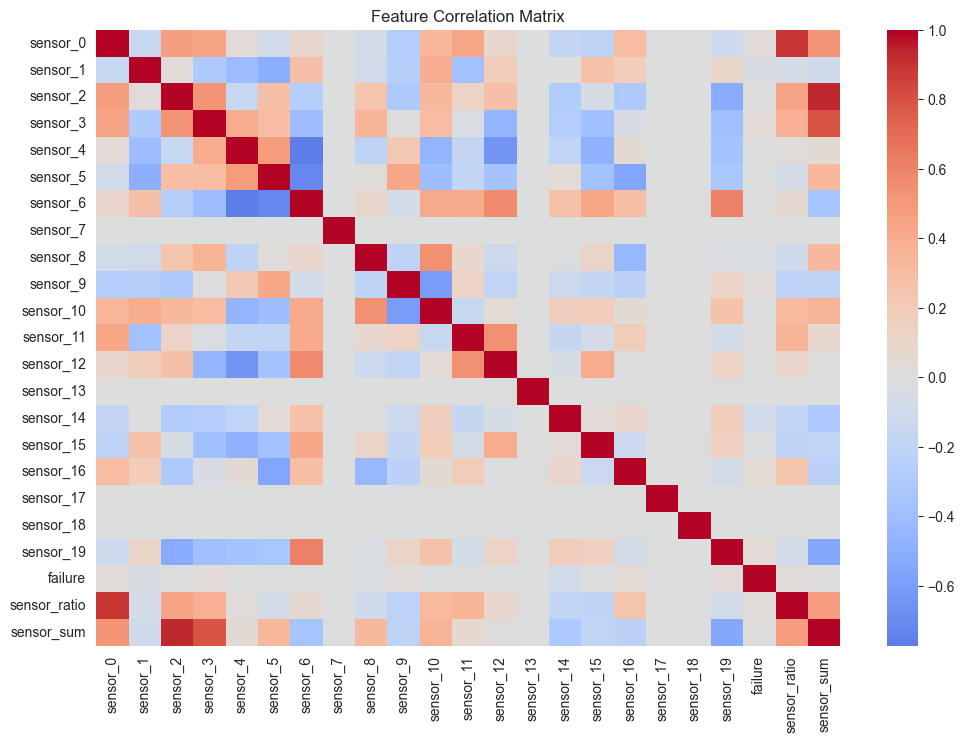

In [7]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

## 8. Train-Test Split

In [8]:
X = df.drop(
    "failure",
    axis=1
)

y = df["failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (80000, 22)
Testing Shape: (20000, 22)


## 9. Outlier Treatment Transformer

In [9]:
class OutlierCapper(
    BaseEstimator,
    TransformerMixin
):

    def fit(self, X, y=None):

        self.lower_ = np.percentile(
            X,
            1,
            axis=0
        )

        self.upper_ = np.percentile(
            X,
            99,
            axis=0
        )

        return self

    def transform(self, X):

        return np.clip(
            X,
            self.lower_,
            self.upper_
        )

## 11. Logistic Regression Pipeline

In [10]:
lr_pipeline = Pipeline([
    ("outlier", OutlierCapper()),
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

## 12. Train Logistic Regression

In [11]:
lr_pipeline.fit(
    X_train,
    y_train
)

lr_probs = (
    lr_pipeline
    .predict_proba(X_test)[:,1]
)

lr_preds = (
    lr_probs >= 0.5
).astype(int)

print("Logistic Regression Training Completed")

Logistic Regression Training Completed


## 13. Random Forest Pipeline

In [12]:
rf_pipeline = Pipeline([
    ("outlier", OutlierCapper()),
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    (
        "model",
        RandomForestClassifier(
            class_weight="balanced",
            random_state=42
        )
    )
])

## 14. Hyperparameter Tuning

In [13]:
param_grid = {
    "model__n_estimators":[100,200],
    "model__max_depth":[5,10,None]
}

grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(
    X_train,
    y_train
)

best_model = (
    grid.best_estimator_
)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters:
{'model__max_depth': None, 'model__n_estimators': 200}

Best CV Score:
0.5556510749239132


## 15. Best Model Selection

In [14]:
print(best_model)

Pipeline(steps=[('outlier', OutlierCapper()), ('scaler', StandardScaler()),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])


## 16. Generate Predictions

In [15]:
rf_probs = (
    best_model
    .predict_proba(X_test)[:,1]
)

rf_preds = (
    rf_probs >= 0.5
).astype(int)

## 17. Evaluation Function

In [16]:
def evaluate_model(
    y_true,
    preds,
    probs
):

    print("=" * 50)

    print(
        "Precision:",
        round(
            precision_score(
                y_true,
                preds
            ),
            4
        )
    )

    print(
        "Recall:",
        round(
            recall_score(
                y_true,
                preds
            ),
            4
        )
    )

    print(
        "F1 Score:",
        round(
            f1_score(
                y_true,
                preds
            ),
            4
        )
    )

    print(
        "ROC-AUC:",
        round(
            roc_auc_score(
                y_true,
                probs
            ),
            4
        )
    )

    print(
        "PR-AUC:",
        round(
            average_precision_score(
                y_true,
                probs
            ),
            4
        )
    )

    print("\nConfusion Matrix")

    print(
        confusion_matrix(
            y_true,
            preds
        )
    )

    print("\nClassification Report")

    print(
        classification_report(
            y_true,
            preds
        )
    )

## 18. Logistic Regression Results

In [17]:
print("LOGISTIC REGRESSION")

evaluate_model(
    y_test,
    lr_preds,
    lr_probs
)

LOGISTIC REGRESSION
Precision: 0.0217
Recall: 0.81
F1 Score: 0.0422
ROC-AUC: 0.898
PR-AUC: 0.1179

Confusion Matrix
[[16243  3657]
 [   19    81]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.82      0.90     19900
           1       0.02      0.81      0.04       100

    accuracy                           0.82     20000
   macro avg       0.51      0.81      0.47     20000
weighted avg       0.99      0.82      0.89     20000



## 19. Random Forest Results

In [18]:
print("RANDOM FOREST")

evaluate_model(
    y_test,
    rf_preds,
    rf_probs
)

RANDOM FOREST
Precision: 0.7321
Recall: 0.41
F1 Score: 0.5256
ROC-AUC: 0.9932
PR-AUC: 0.6224

Confusion Matrix
[[19885    15]
 [   59    41]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19900
           1       0.73      0.41      0.53       100

    accuracy                           1.00     20000
   macro avg       0.86      0.70      0.76     20000
weighted avg       1.00      1.00      1.00     20000



## 20. Model Comparison

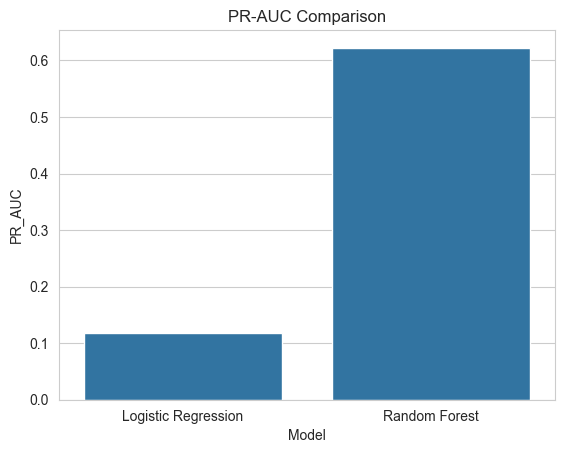

In [29]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "PR_AUC": [
        average_precision_score(y_test, lr_probs),
        average_precision_score(y_test, rf_probs)
    ]
})

sns.barplot(
    data=comparison_df,
    x="Model",
    y="PR_AUC"
)

plt.title("PR-AUC Comparison")

plt.show()

## 21. ROC Curve

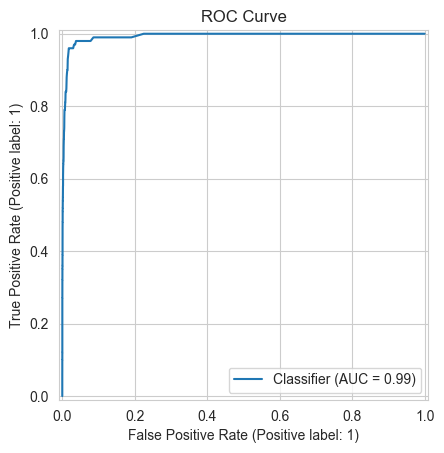

In [30]:
RocCurveDisplay.from_predictions(
    y_test,
    rf_probs
)

plt.title("ROC Curve")

plt.show()

## 22. Precision-Recall Curve

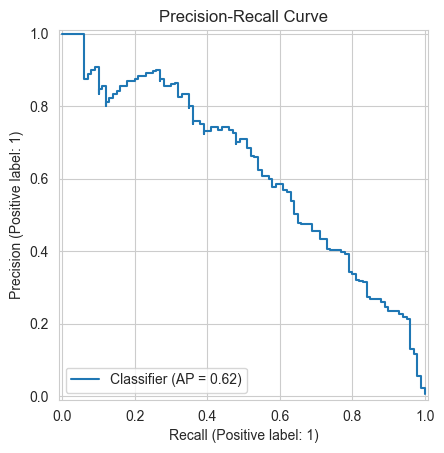

In [21]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    rf_probs
)

plt.title("Precision-Recall Curve")

plt.show()

## Why PR-AUC?

Accuracy is misleading for highly imbalanced datasets.

A model predicting every machine as healthy would still achieve approximately 99.5% accuracy.

Therefore PR-AUC is selected as the primary evaluation metric because it focuses directly on the minority class (machine failures).

## 24. Business Threshold Optimization

In [22]:
fn_cost = 100

fp_cost = 1

threshold = (
    fp_cost /
    (fp_cost + fn_cost)
)

print(
    "Business Threshold:",
    threshold
)

Business Threshold: 0.009900990099009901


## 25. Business Threshold Results

In [23]:
business_preds = (
    rf_probs >= threshold
).astype(int)

print("BUSINESS THRESHOLD RESULTS")

evaluate_model(
    y_test,
    business_preds,
    rf_probs
)

BUSINESS THRESHOLD RESULTS
Precision: 0.0114
Recall: 1.0
F1 Score: 0.0225
ROC-AUC: 0.9932
PR-AUC: 0.6224

Confusion Matrix
[[11211  8689]
 [    0   100]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.56      0.72     19900
           1       0.01      1.00      0.02       100

    accuracy                           0.57     20000
   macro avg       0.51      0.78      0.37     20000
weighted avg       1.00      0.57      0.72     20000



## 26. Save Final Model

In [25]:
joblib.dump(
    best_model,
    "predictive_maintenance_model.pkl"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully


## Feature Importance Analysis

Random Forest models provide feature importance scores that indicate how much each feature contributes to the prediction process.

Feature importance helps:

- Identify the most influential sensor readings
- Improve model interpretability
- Understand which operational signals are most associated with machine failures
- Support future feature selection and monitoring strategies

The following visualization displays the top 10 most important features identified by the optimized Random Forest model.

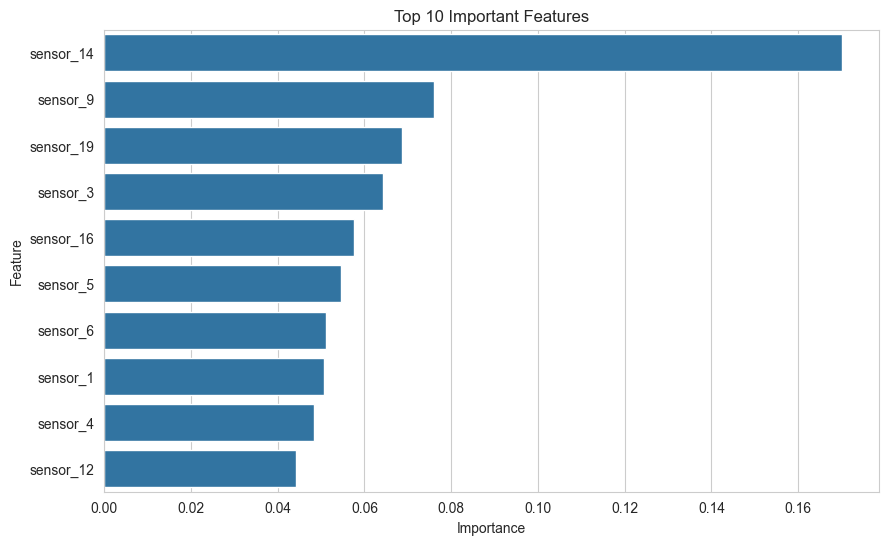

In [26]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.named_steps["model"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

### Interpretation

The chart shows the top 10 features that contributed most to machine failure prediction.

Features with higher importance values have a greater influence on model decisions. These features can be considered critical indicators of machine health and may be prioritized for monitoring in a real-world predictive maintenance system.

Feature importance analysis improves transparency and provides insights into the factors driving model predictions.

## 27. Conclusion



This project successfully developed a predictive maintenance solution for a highly imbalanced manufacturing dataset.

Key Achievements:

- Generated a synthetic dataset with approximately 0.5% failures
- Applied feature engineering
- Built end-to-end machine learning pipelines
- Addressed class imbalance using SMOTE and class weighting
- Tuned model hyperparameters using GridSearchCV
- Evaluated models using PR-AUC, ROC-AUC, Precision, Recall, and F1 Score
- Implemented business-aware threshold optimization

The Random Forest model achieved the strongest overall performance and was selected as the final deployment candidate.